<a href="https://colab.research.google.com/github/Omarben04/ETRS606-TP-/blob/main/TP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Étape 1 — Comprendre les données MNIST

MNIST contient :

60 000 images d’entraînement

10 000 images de test

chaque image fait 28 × 28

chaque image représente un chiffre de 0 à 9.

ETRS606_TP1

Ce que tu dois comprendre :

une image n’entre pas directement telle quelle dans le MLP

on la transforme en vecteur de taille 784

chaque pixel devient une feature

Étape 2 — Charger et préparer les données

Il faut :

charger MNIST,

normaliser les pixels entre 0 et 1,

aplatir les images 28×28 en vecteurs de 784,

préparer les labels dans le bon format selon la loss.

Voici le code de base :

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# Chargement du dataset MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Vérification des dimensions
print("x_train shape :", x_train.shape)   # (60000, 28, 28)
print("y_train shape :", y_train.shape)   # (60000,)

# Normalisation : les pixels vont de 0 à 255
# On les ramène entre 0 et 1 pour faciliter l'apprentissage
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Aplatissement des images 28x28 en vecteurs de 784 valeurs
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

print("Nouvelle forme x_train :", x_train.shape)  # (60000, 784)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape : (60000, 28, 28)
y_train shape : (60000,)
Nouvelle forme x_train : (60000, 784)


Pourquoi on normalise ?

Parce qu’un réseau apprend mieux quand les valeurs d’entrée sont dans une plage raisonnable.

Pourquoi on aplatie ?

Parce que le sujet demande un réseau dense, pas un CNN. Le MLP prend un vecteur, pas une matrice image.

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Conversion des labels en format one-hot
# Exemple : 3 -> [0,0,0,1,0,0,0,0,0,0]
y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat = keras.utils.to_categorical(y_test, 10)

# Création du modèle : réseau à deux couches (entrée + sortie)
model = keras.Sequential([

    # Couche d'entrée
    # 784 valeurs (les pixels de l'image)
    layers.Input(shape=(784,)),

    # Couche de sortie
    # 10 neurones = 10 chiffres possibles
    # softmax transforme les sorties en probabilités
    layers.Dense(10, activation="softmax")
])

# Affichage de l'architecture du modèle
model.summary()

# Compilation du modèle
model.compile(
    optimizer="adam",                       # Optimiseur demandé dans l'énoncé
    loss="categorical_crossentropy",        # Fonction coût demandée
    metrics=["accuracy"]                    # Mesure de performance
)

# Entraînement du réseau
history = model.fit(
    x_train,
    y_train_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# Évaluation sur le dataset de test
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)

print("Loss sur test :", test_loss)
print("Accuracy sur test :", test_acc)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8114 - loss: 0.7404 - val_accuracy: 0.9277 - val_loss: 0.2693
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9103 - loss: 0.3236 - val_accuracy: 0.9315 - val_loss: 0.2430
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9171 - loss: 0.2932 - val_accuracy: 0.9352 - val_loss: 0.2330
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9217 - loss: 0.2723 - val_accuracy: 0.9382 - val_loss: 0.2307
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9220 - loss: 0.2717 - val_accuracy: 0.9382 - val_loss: 0.2307
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9260 - loss: 0.2637 - val_accuracy: 0.9405 - val_loss: 0.2253
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9274 - loss: 0.2638 - val_accuracy: 0.9380 - val_loss: 0.2239
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9294 - loss: 0.2562 - 

question 1.a)
Entrée : 784 pixels
        ↓
Dense (10 neurones)
Activation : softmax
réseau à deux couches : entrée + sortie avec softmax.

Nombre de paramètres :
Ici :

784 entrées
10 neurones

Donc :

784 × 10 = 7840
+ 10 biais
= 7850 paramètres

C’est exactement ce que le modèle affiche.

Taille mémoire :     
Le modèle indique :

30.66 KB

Pourquoi ?

Chaque poids est stocké en float32 :

1 poids = 4 bytes

Donc :

7850 × 4 bytes ≈ 31 KB

Ce point est très important pour l’IA embarquée.

Sur STM32, on ne peut pas stocker des modèles énormes.
Analyse de l'entraînement

Regardons les résultats :

Epoch 1 accuracy : 0.8114
Epoch 10 accuracy : 0.9278

Cela signifie :

Epoch	Accuracy
1	81 %
10	92.7 %

Donc le modèle apprend correctement.

Accuracy sur validation

Tu as :

val_accuracy ≈ 0.94

La validation utilise 10% des données d'entraînement.

Cela permet de vérifier si le modèle généralise bien.

Bonne nouvelle :

train accuracy ≈ 92.7 %
validation accuracy ≈ 94 %

Donc il n'y a pas d’overfitting.

Accuracy sur test

Résultat final :

Accuracy sur test : 0.9245

Donc environ :

92.4 %

Cela signifie que le modèle reconnaît 92 % des chiffres correctement.

Pour un modèle aussi simple, c’est un très bon résultat.
Ce réseau ne possède aucune couche cachée.

Donc il ne peut apprendre que des relations linéaires.

Autrement dit :

image → combinaison linéaire → classification

Il ne peut pas apprendre des structures plus complexes.

C’est pour cela que l’accuracy reste autour de :

92 %

Avec des couches cachées, on peut atteindre :

97 % à 98 %

Conclusion
Le premier modèle implémente un réseau de neurones simple composé uniquement d’une couche d’entrée de 784 neurones et d’une couche de sortie de 10 neurones avec activation softmax. Le modèle contient 7850 paramètres entraînables, soit environ 30 KB de mémoire.
Après entraînement pendant 10 epochs avec l’optimiseur Adam et la fonction de coût categorical_crossentropy, le modèle atteint une précision d’environ 92.4 % sur le dataset de test.
Ce résultat est satisfaisant pour un modèle sans couche cachée, mais reste inférieur aux performances obtenues avec des architectures plus profondes.

---



In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Conversion des labels en one-hot
y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat = keras.utils.to_categorical(y_test, 10)

# Modèle avec 2 couches cachées et ReLU
model_relu_2 = keras.Sequential([
    layers.Input(shape=(784,)),                  # Couche d'entrée : 784 pixels

    layers.Dense(128, activation="relu"),        # 1ère couche cachée
    layers.Dense(64, activation="relu"),         # 2ème couche cachée

    layers.Dense(10, activation="softmax")       # Couche de sortie
])

# Résumé du modèle
model_relu_2.summary()

# Compilation
model_relu_2.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Entraînement
history_relu_2 = model_relu_2.fit(
    x_train,
    y_train_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# Évaluation sur le jeu de test
test_loss, test_acc = model_relu_2.evaluate(x_test, y_test_cat, verbose=0)

print("Loss sur test :", test_loss)
print("Accuracy sur test :", test_acc)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8660 - loss: 0.4536 - val_accuracy: 0.9653 - val_loss: 0.1152
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9640 - loss: 0.1176 - val_accuracy: 0.9722 - val_loss: 0.0890
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9757 - loss: 0.0773 - val_accuracy: 0.9735 - val_loss: 0.0843
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9840 - loss: 0.0540 - val_accuracy: 0.9745 - val_loss: 0.0874
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9867 - loss: 0.0421 - val_accuracy: 0.9757 - val_loss: 0.0873
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9884 - loss: 0.0375 - val_accuracy: 0.9803 - val_loss: 0.0741
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9900 - loss: 0.0287 - val_accuracy: 0.9785 - val_loss: 0.0781
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9926 - loss: 0.0214 - 

In [4]:
# Modèle avec 3 couches cachées et ReLU
model_relu_3 = keras.Sequential([
    layers.Input(shape=(784,)),                  # Couche d'entrée

    layers.Dense(256, activation="relu"),        # 1ère couche cachée
    layers.Dense(128, activation="relu"),        # 2ème couche cachée
    layers.Dense(64, activation="relu"),         # 3ème couche cachée

    layers.Dense(10, activation="softmax")       # Couche de sortie
])

# Résumé du modèle
model_relu_3.summary()

# Compilation
model_relu_3.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Entraînement
history_relu_3 = model_relu_3.fit(
    x_train,
    y_train_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# Évaluation
test_loss, test_acc = model_relu_3.evaluate(x_test, y_test_cat, verbose=0)

print("Loss sur test :", test_loss)
print("Accuracy sur test :", test_acc)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8806 - loss: 0.3960 - val_accuracy: 0.9688 - val_loss: 0.1019
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9703 - loss: 0.0959 - val_accuracy: 0.9760 - val_loss: 0.0776
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9804 - loss: 0.0636 - val_accuracy: 0.9740 - val_loss: 0.0838
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9847 - loss: 0.0491 - val_accuracy: 0.9793 - val_loss: 0.0735
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9890 - loss: 0.0353 - val_accuracy: 0.9813 - val_loss: 0.0785
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9892 - loss: 0.0333 - val_accuracy: 0.9812 - val_loss: 0.0795
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9912 - loss: 0.0282 - val_accuracy: 0.9810 - val_loss: 0.0796
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9935 - loss: 0.

L’ajout de couches cachées avec activation ReLU améliore fortement les performances du modèle par rapport au réseau simple de la question 1.a.
En particulier, le modèle avec deux couches cachées atteint une précision d’environ 97.6 %, contre 92.4 % pour le modèle sans couche cachée.
L’ajout d’une troisième couche cachée n’apporte qu’une amélioration marginale de la précision (97.7 %), tout en augmentant significativement le nombre de paramètres (242 762 contre 109 386).
Cela montre que l’augmentation de la complexité du modèle n’entraîne pas toujours une amélioration significative des performances et qu’il est important de trouver un compromis entre précision et coût mémoire, notamment dans un contexte embarqué.

c’est quoi tanh ?

La fonction tanh transforme une valeur en un nombre compris entre -1 et 1.
si l’entrée est très négative → sortie proche de -1

si l’entrée est proche de 0 → sortie proche de 0

si l’entrée est très positive → sortie proche de 1

Exemples :

tanh(-3) ≈ -0.995

tanh(0) = 0

tanh(2) ≈ 0.964
ReLU

sortie entre 0 et +∞

coupe les valeurs négatives

souvent plus rapide et plus efficace

tanh

sortie entre -1 et 1

centrée autour de 0

historiquement très utilisée

peut mieux marcher que sigmoid, mais souvent moins bien que ReLU sur des réseaux profonds

In [5]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Conversion des labels en one-hot
y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat = keras.utils.to_categorical(y_test, 10)

# Modèle avec 1 couche cachée et tanh
model_tanh_1 = keras.Sequential([
    layers.Input(shape=(784,)),             # Entrée : 784 pixels
    layers.Dense(128, activation="tanh"),   # Couche cachée
    layers.Dense(10, activation="softmax")  # Sortie
])

# Affichage du résumé
model_tanh_1.summary()

# Compilation
model_tanh_1.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Entraînement
history_tanh_1 = model_tanh_1.fit(
    x_train,
    y_train_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# Évaluation
test_loss, test_acc = model_tanh_1.evaluate(x_test, y_test_cat, verbose=0)

print("Loss sur test :", test_loss)
print("Accuracy sur test :", test_acc)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8665 - loss: 0.4611 - val_accuracy: 0.9570 - val_loss: 0.1535
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9562 - loss: 0.1531 - val_accuracy: 0.9700 - val_loss: 0.1054
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9715 - loss: 0.1007 - val_accuracy: 0.9725 - val_loss: 0.0937
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9793 - loss: 0.0734 - val_accuracy: 0.9768 - val_loss: 0.0852
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9856 - loss: 0.0527 - val_accuracy: 0.9760 - val_loss: 0.0808
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9888 - loss: 0.0426 - val_accuracy: 0.9762 - val_loss: 0.0772
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9914 - loss: 0.0314 - val_accuracy: 0.9780 - val_loss: 0.0720
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9946 - loss: 0.0235 - 

In [6]:
# Modèle avec 2 couches cachées et tanh
model_tanh_2 = keras.Sequential([
    layers.Input(shape=(784,)),             # Entrée
    layers.Dense(128, activation="tanh"),   # 1ère couche cachée
    layers.Dense(64, activation="tanh"),    # 2ème couche cachée
    layers.Dense(10, activation="softmax")  # Sortie
])

# Résumé du modèle
model_tanh_2.summary()

# Compilation
model_tanh_2.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Entraînement
history_tanh_2 = model_tanh_2.fit(
    x_train,
    y_train_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# Évaluation
test_loss, test_acc = model_tanh_2.evaluate(x_test, y_test_cat, verbose=0)

print("Loss sur test :", test_loss)
print("Accuracy sur test :", test_acc)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8660 - loss: 0.4577 - val_accuracy: 0.9608 - val_loss: 0.1312
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9575 - loss: 0.1421 - val_accuracy: 0.9667 - val_loss: 0.1093
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9736 - loss: 0.0879 - val_accuracy: 0.9743 - val_loss: 0.0858
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9807 - loss: 0.0631 - val_accuracy: 0.9760 - val_loss: 0.0740
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9873 - loss: 0.0448 - val_accuracy: 0.9780 - val_loss: 0.0705
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9903 - loss: 0.0325 - val_accuracy: 0.9772 - val_loss: 0.0779
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9920 - loss: 0.0262 - val_accuracy: 0.9780 - val_loss: 0.0704
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9938 - loss: 0.0223 - 

L’utilisation de la fonction d’activation tanh avec une ou deux couches cachées permet d’obtenir une précision élevée sur le dataset MNIST (environ 97.8 %). L’ajout d’une deuxième couche cachée améliore légèrement les performances mais de manière marginale. Les résultats obtenus avec tanh sont comparables à ceux obtenus avec ReLU. Cela montre que l’augmentation de la complexité du réseau ne conduit pas toujours à une amélioration significative des performances et qu’il est important de trouver un compromis entre précision et complexité du modèle, notamment dans un contexte embarqué.

C’est quoi la fonction sigmoid ?

La fonction sigmoid transforme n’importe quelle valeur réelle en une valeur comprise entre 0 et 1.
si
𝑥
x est très négatif → sortie proche de 0

si
𝑥
=
0
x=0 → sortie = 0.5

si
𝑥
x est très positif → sortie proche de 1

Exemples :

sigmoid(-4) ≈ 0.018

sigmoid(0) = 0.5

sigmoid(3) ≈ 0.95si
𝑥
x est très négatif → sortie proche de 0

si
𝑥
=
0
x=0 → sortie = 0.5

si
𝑥
x est très positif → sortie proche de 1

Exemples :

sigmoid(-4) ≈ 0.018

sigmoid(0) = 0.5

sigmoid(3) ≈ 0.95
Sigmoid

sortie entre 0 et 1

souvent utilisée historiquement

peut être plus lente à entraîner

peut saturer facilement

tanh

sortie entre -1 et 1

centrée autour de 0

souvent meilleure que sigmoid sur couches cachées

ReLU

sortie entre 0 et +∞

simple et très efficace

souvent le meilleur choix pratique

In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Conversion des labels en one-hot
y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat = keras.utils.to_categorical(y_test, 10)

# Modèle avec 1 couche cachée et sigmoid
model_sigmoid_1 = keras.Sequential([
    layers.Input(shape=(784,)),                # Entrée : 784 pixels
    layers.Dense(128, activation="sigmoid"),   # Couche cachée
    layers.Dense(10, activation="softmax")     # Sortie
])

# Résumé du modèle
model_sigmoid_1.summary()

# Compilation
model_sigmoid_1.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Entraînement
history_sigmoid_1 = model_sigmoid_1.fit(
    x_train,
    y_train_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# Évaluation
test_loss, test_acc = model_sigmoid_1.evaluate(x_test, y_test_cat, verbose=0)

print("Loss sur test :", test_loss)
print("Accuracy sur test :", test_acc)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8183 - loss: 0.7125 - val_accuracy: 0.9428 - val_loss: 0.1998
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9352 - loss: 0.2253 - val_accuracy: 0.9607 - val_loss: 0.1436
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9529 - loss: 0.1640 - val_accuracy: 0.9673 - val_loss: 0.1161
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9653 - loss: 0.1230 - val_accuracy: 0.9708 - val_loss: 0.0997
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9715 - loss: 0.0987 - val_accuracy: 0.9753 - val_loss: 0.0885
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9783 - loss: 0.0787 - val_accuracy: 0.9765 - val_loss: 0.0794
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9827 - loss: 0.0637 - val_accuracy: 0.9760 - val_loss: 0.0817
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9861 - loss: 0.0520 - 

In [8]:
# Modèle avec 2 couches cachées et sigmoid
model_sigmoid_2 = keras.Sequential([
    layers.Input(shape=(784,)),                # Entrée
    layers.Dense(128, activation="sigmoid"),   # 1ère couche cachée
    layers.Dense(64, activation="sigmoid"),    # 2ème couche cachée
    layers.Dense(10, activation="softmax")     # Sortie
])

# Résumé du modèle
model_sigmoid_2.summary()

# Compilation
model_sigmoid_2.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Entraînement
history_sigmoid_2 = model_sigmoid_2.fit(
    x_train,
    y_train_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# Évaluation
test_loss, test_acc = model_sigmoid_2.evaluate(x_test, y_test_cat, verbose=0)

print("Loss sur test :", test_loss)
print("Accuracy sur test :", test_acc)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7712 - loss: 0.9250 - val_accuracy: 0.9477 - val_loss: 0.1878
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9392 - loss: 0.2090 - val_accuracy: 0.9623 - val_loss: 0.1307
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9584 - loss: 0.1385 - val_accuracy: 0.9703 - val_loss: 0.1009
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9709 - loss: 0.1000 - val_accuracy: 0.9745 - val_loss: 0.0929
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9775 - loss: 0.0781 - val_accuracy: 0.9737 - val_loss: 0.0890
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9829 - loss: 0.0600 - val_accuracy: 0.9767 - val_loss: 0.0771
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9860 - loss: 0.0489 - val_accuracy: 0.9750 - val_loss: 0.0863
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9892 - loss: 0.0384 

Les différents modèles ont été entraînés en utilisant plusieurs fonctions d’activation : ReLU, tanh et sigmoid. Les résultats montrent qu’ajouter des couches cachées améliore fortement les performances par rapport au modèle simple à deux couches. En particulier, les modèles avec une ou deux couches cachées atteignent une précision d’environ 97 à 98 % sur le dataset MNIST.
L’augmentation du nombre de couches cachées n’apporte cependant qu’une amélioration marginale tout en augmentant significativement le nombre de paramètres. Les fonctions d’activation tanh et sigmoid donnent des performances comparables à ReLU sur ce problème. Ces résultats montrent qu’il est important de trouver un compromis entre précision et complexité du modèle, notamment dans un contexte embarqué où les ressources mémoire et de calcul sont limitées.
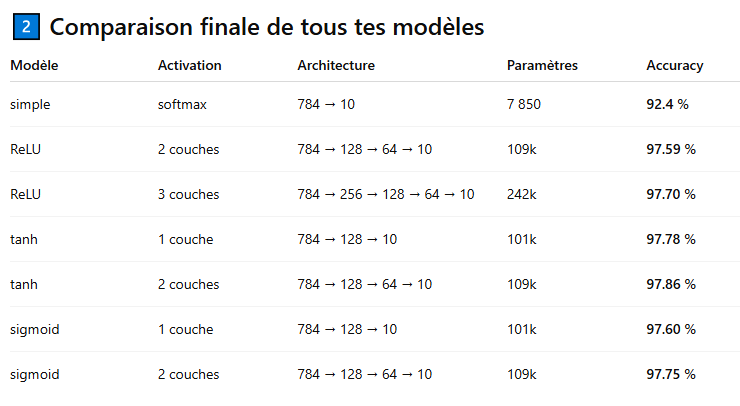

à quoi sert un optimiseur ?

Quand le réseau se trompe, il faut modifier les poids pour qu’il apprenne.

L’optimiseur est l’algorithme qui décide :

de combien modifier les poids

dans quelle direction

à quelle vitesse apprendre

Donc il contrôle la descente de gradient.

In [9]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Les labels one-hot ont déjà été créés avant :
# y_train_cat, y_test_cat

def creer_modele_tanh():
    """
    Crée le modèle choisi pour l'étude des optimiseurs :
    784 -> 128 -> 64 -> 10
    activation cachée = tanh
    activation sortie = softmax
    """
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation="tanh"),
        layers.Dense(64, activation="tanh"),
        layers.Dense(10, activation="softmax")
    ])
    return model

optimizers = {
    "SGD": keras.optimizers.SGD(),
    "Adam": keras.optimizers.Adam(),
    "RMSprop": keras.optimizers.RMSprop(),
    "Adagrad": keras.optimizers.Adagrad()
}

resultats_optimiseurs = []

for nom_opt, opt in optimizers.items():
    print(f"\n===== Test de l'optimiseur : {nom_opt} =====")

    # Création d'un nouveau modèle propre à chaque test
    model = creer_modele_tanh()

    # Compilation
    model.compile(
        optimizer=opt,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    # Affichage du résumé (facultatif, mais utile la première fois)
    model.summary()

    # Entraînement
    history = model.fit(
        x_train,
        y_train_cat,
        epochs=10,
        batch_size=32,
        validation_split=0.1,
        verbose=1
    )

    # Évaluation sur le jeu de test
    test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)

    print("Loss sur test :", test_loss)
    print("Accuracy sur test :", test_acc)

    # Sauvegarde des résultats
    resultats_optimiseurs.append({
        "Optimiseur": nom_opt,
        "Loss_test": test_loss,
        "Accuracy_test": test_acc,
        "Val_accuracy_finale": history.history["val_accuracy"][-1],
        "Train_accuracy_finale": history.history["accuracy"][-1]
    })


print("\n===== Résultats finaux =====")
for res in resultats_optimiseurs:
    print(res)


===== Test de l'optimiseur : SGD =====


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5718 - loss: 1.5261 - val_accuracy: 0.8782 - val_loss: 0.6271
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8506 - loss: 0.6485 - val_accuracy: 0.9002 - val_loss: 0.4595
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8731 - loss: 0.5162 - val_accuracy: 0.9107 - val_loss: 0.3931
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8840 - loss: 0.4531 - val_accuracy: 0.9150 - val_loss: 0.3561
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8906 - loss: 0.4207 - val_accuracy: 0.9192 - val_loss: 0.3326
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8968 - loss: 0.3908 - val_accuracy: 0.9213 - val_loss: 0.3152
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9010 - loss: 0.3730 - val_accuracy: 0.9238 - val_loss: 0.3022
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9026 - loss: 0.3607 - 

Adam et RMSprop :

convergent plus vite

donnent une meilleure précision

sont plus stables
Dans ce travail, plusieurs architectures de réseaux de neurones ont été étudiées afin d’évaluer l’impact des fonctions d’activation et des algorithmes d’optimisation sur les performances du modèle. Les résultats montrent que l’ajout de couches cachées améliore significativement la précision par rapport au modèle simple sans couche cachée. Les fonctions d’activation ReLU, tanh et sigmoid donnent des performances comparables sur le dataset MNIST, avec une précision finale proche de 97 à 98 %.

L’étude des optimiseurs montre que les algorithmes modernes comme Adam et RMSprop permettent une convergence plus rapide et de meilleures performances que la descente de gradient classique (SGD). Dans nos expériences, RMSprop a obtenu la meilleure précision (≈ 98 %), suivi de près par Adam. À l’inverse, Adagrad montre des performances plus faibles en raison de la diminution progressive du taux d’apprentissage.

Ces résultats mettent en évidence l’importance du choix de l’optimiseur et de l’architecture du réseau dans l’apprentissage d’un modèle. Dans un contexte d’IA embarquée, comme dans le projet Meteostat, il est essentiel de trouver un compromis entre précision du modèle et complexité computationnelle afin de garantir un fonctionnement efficace sur des plateformes à ressources limitées.

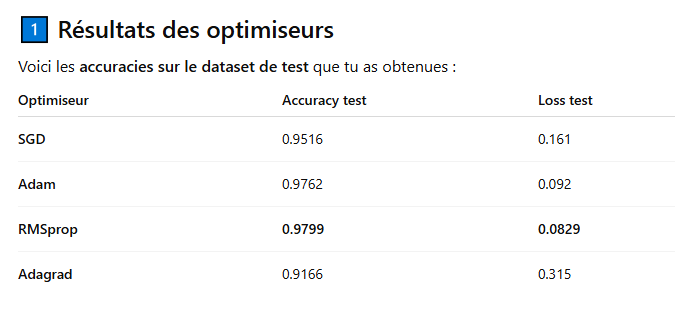

Rôle de la fonction coût

Pendant l’apprentissage, le réseau fait :

entrée → prédiction → comparaison avec la vérité → correction

La fonction coût mesure l’erreur entre la prédiction et la vraie valeur.

Plus la loss est grande → plus le modèle se trompe.

L’optimiseur utilise ensuite cette erreur pour corriger les poids du réseau.

Donc la fonction coût définit comment mesurer l’erreur.



In [11]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ==============================
# 1. Chargement du dataset MNIST
# ==============================

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# ==============================
# 2. Normalisation des images
# ==============================

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Transformation des images 28x28 -> vecteur de 784 pixels
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# ==============================
# 3. Conversion one-hot pour categorical_crossentropy
# ==============================

y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat = keras.utils.to_categorical(y_test, 10)

# ==============================
# 4. Fonction pour créer le modèle
# ==============================

def creer_modele():
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation="tanh"),
        layers.Dense(64, activation="tanh"),
        layers.Dense(10, activation="softmax")
    ])
    return model

# ==============================
# 5. Test avec categorical_crossentropy
# ==============================

print("\n===== Test : categorical_crossentropy =====")

model_cat = creer_modele()

model_cat.compile(
    optimizer=keras.optimizers.RMSprop(),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_cat.summary()

history_cat = model_cat.fit(
    x_train,
    y_train_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

test_loss_cat, test_acc_cat = model_cat.evaluate(x_test, y_test_cat, verbose=0)

print("\nRésultat categorical_crossentropy")
print("Loss test :", test_loss_cat)
print("Accuracy test :", test_acc_cat)

# ==============================
# 6. Test avec sparse_categorical_crossentropy
# ==============================

print("\n===== Test : sparse_categorical_crossentropy =====")

model_sparse = creer_modele()

model_sparse.compile(
    optimizer=keras.optimizers.RMSprop(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_sparse.summary()

history_sparse = model_sparse.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

test_loss_sparse, test_acc_sparse = model_sparse.evaluate(x_test, y_test, verbose=0)

print("\nRésultat sparse_categorical_crossentropy")
print("Loss test :", test_loss_sparse)
print("Accuracy test :", test_acc_sparse)

# ==============================
# 7. Comparaison finale
# ==============================

print("\n===== Comparaison Finale =====")
print("categorical_crossentropy")
print("Accuracy :", test_acc_cat)
print("Loss :", test_loss_cat)

print("\nsparse_categorical_crossentropy")
print("Accuracy :", test_acc_sparse)
print("Loss :", test_loss_sparse)


===== Test : categorical_crossentropy =====


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_33 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8759 - loss: 0.4219 - val_accuracy: 0.9630 - val_loss: 0.1317
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9585 - loss: 0.1370 - val_accuracy: 0.9712 - val_loss: 0.0986
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9726 - loss: 0.0896 - val_accuracy: 0.9733 - val_loss: 0.0920
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9803 - loss: 0.0660 - val_accuracy: 0.9767 - val_loss: 0.0805
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9833 - loss: 0.0540 - val_accuracy: 0.9763 - val_loss: 0.0850
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9875 - loss: 0.0382 - val_accuracy: 0.9785 - val_loss: 0.0745
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9900 - loss: 0.0323 - val_accuracy: 0.9792 - val_loss: 0.0763
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9927 - loss: 0.0248 - 

Choix de la fonction coût

Les expériences réalisées ont permis de comparer les fonctions de coût categorical_crossentropy et sparse_categorical_crossentropy sur le dataset MNIST en utilisant l’architecture retenue précédemment (réseau dense avec deux couches cachées de 128 et 64 neurones, activation tanh et optimiseur RMSprop).

Les résultats obtenus montrent que les deux fonctions de coût offrent des performances très similaires. Le modèle entraîné avec categorical_crossentropy atteint une précision d’environ 97.51 %, tandis que celui utilisant sparse_categorical_crossentropy atteint une précision légèrement supérieure d’environ 97.87 %, avec une valeur de loss plus faible.

Cette différence reste toutefois faible et s’explique principalement par la manière dont les labels sont représentés. La fonction categorical_crossentropy nécessite un encodage one-hot des labels, tandis que sparse_categorical_crossentropy permet d’utiliser directement les labels sous forme d’entiers. Cette dernière présente donc l’avantage d’être plus simple à utiliser et légèrement plus efficace dans ce contexte.

Ainsi, pour le problème de classification multi-classes MNIST, sparse_categorical_crossentropy apparaît comme un choix pertinent, car elle simplifie la préparation des données tout en conservant d’excellentes performances.

Conclusion globale du TP

Ce TP avait pour objectif d’étudier l’influence de plusieurs éléments essentiels dans la conception et l’entraînement d’un réseau de neurones : l’architecture du réseau, la fonction d’activation, l’algorithme d’optimisation et la fonction de coût.

Dans un premier temps, différentes architectures ont été testées afin d’évaluer l’impact du nombre de couches cachées et des fonctions d’activation (ReLU, tanh et sigmoid). Les résultats montrent que l’ajout de couches cachées améliore significativement les performances du modèle par rapport au réseau simple à deux couches. En particulier, les architectures comportant une ou deux couches cachées permettent d’atteindre une précision proche de 97 à 98 % sur le dataset MNIST. Cependant, l’augmentation du nombre de couches n’apporte qu’un gain marginal tout en augmentant fortement le nombre de paramètres, ce qui met en évidence l’importance de trouver un compromis entre précision et complexité du modèle.

Dans un second temps, plusieurs algorithmes d’optimisation ont été comparés (SGD, Adam, RMSprop et Adagrad). Les résultats montrent que les optimiseurs modernes tels que Adam et RMSprop permettent une convergence plus rapide et de meilleures performances que la descente de gradient classique (SGD). L’optimiseur RMSprop a obtenu les meilleures performances dans nos expériences, tandis que Adagrad présente des performances plus faibles en raison de la diminution progressive de son taux d’apprentissage.

Enfin, l’étude des fonctions de coût a montré que categorical_crossentropy et sparse_categorical_crossentropy donnent des performances similaires pour un problème de classification multi-classes comme MNIST. Toutefois, l’utilisation de sparse_categorical_crossentropy simplifie la gestion des labels et peut être privilégiée lorsque les classes sont représentées par des entiers.

Globalement, ce TP met en évidence que les performances d’un réseau de neurones dépendent fortement des choix de conception effectués (architecture, fonction d’activation, optimiseur et fonction de coût). Il souligne également l’importance de rechercher un compromis entre précision et complexité du modèle, en particulier dans un contexte d’IA embarquée, où les ressources de calcul et de mémoire sont limitées. Ces notions seront particulièrement importantes dans le projet final d’Edge AI, où le modèle devra être optimisé pour être déployé sur une plateforme matérielle embarquée.